In [2]:
import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Metadata 

In [3]:
metadata_dictionary = pd.read_csv('metadata_dictionary.csv')
metadata_dictionary.head()

,Variable,Description
0,patient_id,An identifier for the subject
1,diagnosis,The diagnosis of the subject
2,sudden_death,Whether the subject has had a sudden death or not
3,basal_pattern,Whether the baseline ECG is pathological or not
4,brugada,The diagnosis of the subject


| Variabel | Deskripsi |
|----|---- |
| patient_id | Pengidentifikasi unik untuk setiap pasien |
| diagnosis | Diagnosis untuk pasien | 
| sudden_death | Apakah pasien mengalami kematian mendadak | 
| basal_pattern | Apakah EKG menunjukkan pola Brugada |
| Brugada | Pasien didiagnosis sindrom brugada | 


## Loading the Dataset 

### Reading Metadata

In [4]:
metadata = pd.read_csv('metadata.csv')
metadata.head()

,patient_id,basal_pattern,sudden_death,brugada
0,188981,1,0,1
1,251972,0,0,0
2,265715,0,0,0
3,267628,0,0,0
4,267630,0,0,1


In [5]:
print(f"Total subjects: {len(metadata)}")
print(f"Brugada patients: {(metadata['brugada'] > 0).sum()}")
print(f"Healthy subjects: {(metadata['brugada'] == 0).sum()}")

Total subjects: 363
Brugada patients: 76
Healthy subjects: 287


#### Class Distribution

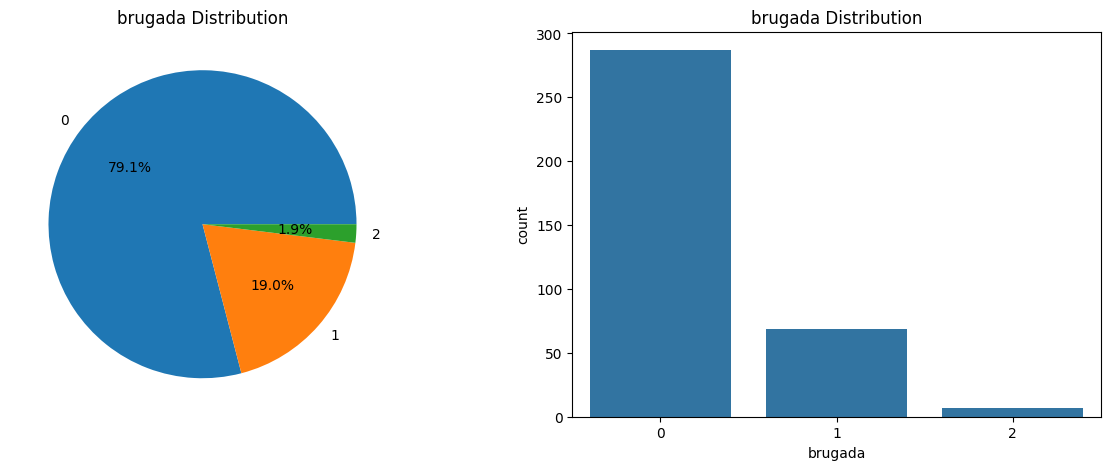

In [6]:
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
counts = metadata["brugada"].value_counts()
plt.pie(counts, labels=counts.index, autopct='%1.1f%%')
plt.title("brugada Distribution")

plt.subplot(1,2,2)
sns.countplot(x=metadata["brugada"])
plt.title("brugada Distribution")
plt.show()

#### Basal Pattern Distribution

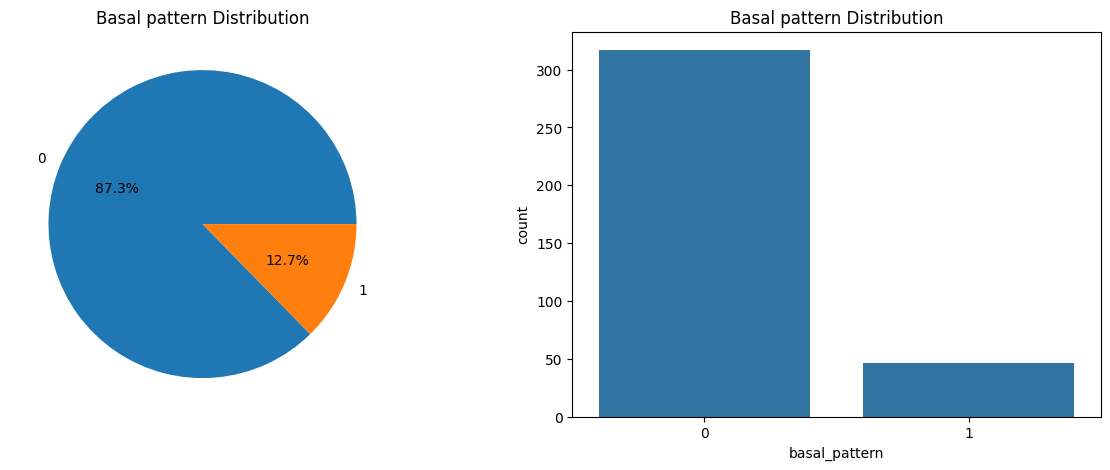

In [7]:
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
counts = metadata["basal_pattern"].value_counts()
plt.pie(counts, labels=counts.index, autopct='%1.1f%%')
plt.title("Basal pattern Distribution")

plt.subplot(1,2,2)
sns.countplot(x=metadata["basal_pattern"])
plt.title("Basal pattern Distribution")
plt.show()

#### Sudden Death Distribution

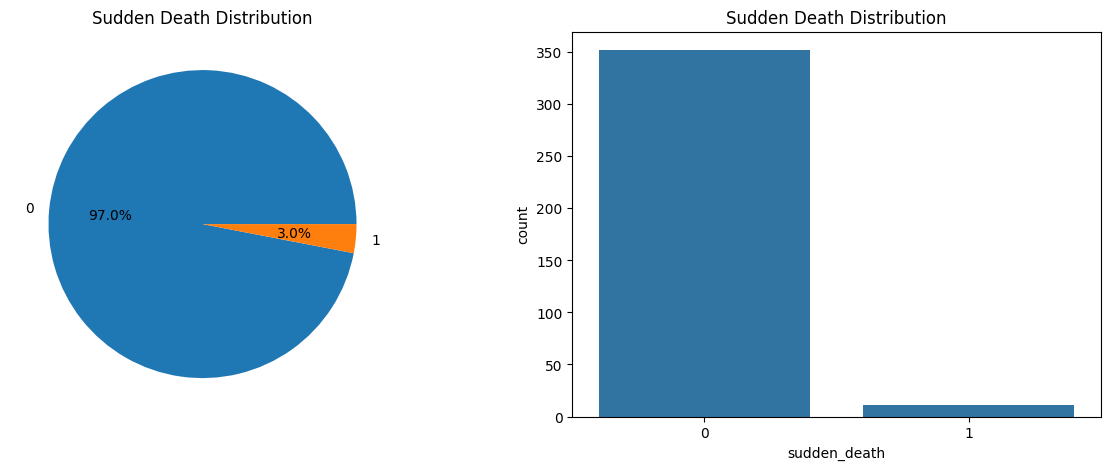

In [8]:
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
counts = metadata["sudden_death"].value_counts()
plt.pie(counts, labels=counts.index, autopct='%1.1f%%')
plt.title("Sudden Death Distribution")

plt.subplot(1,2,2)
sns.countplot(x=metadata["sudden_death"])
plt.title("Sudden Death Distribution")
plt.show()

### Reading ECG (Electrocardiogram) Signals


In [9]:
# patien_id with brugada type 2: 460919
# patiend_id with brugada type 1: 419960
# patiend_id normal: 251972
patient_id = '251972'
record = wfdb.rdrecord(f'files/{patient_id}/{patient_id}')

In [10]:
signals = record.p_signal
lead_names = record.sig_name
sampling_freq = record.fs
duration = len(signals / sampling_freq) 

In [11]:
print(f"Sampling rate: {record.fs} Hz")
print(f"Lead names: {record.sig_name}")
print(f"Duration: {duration} seconds")
print(f"Data shape: {signals.shape}")

Sampling rate: 100 Hz
Lead names: ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
Duration: 1200 seconds
Data shape: (1200, 12)


#### Amplitude Distribution

In [12]:
signal = record.p_signal

print("Min amplitude:", np.min(signal))
print("Max amplitude:", np.max(signal))
print("Mean amplitude:", np.mean(signal))
print("Std amplitude:", np.std(signal))

Min amplitude: -1.592
Max amplitude: 1.78
Mean amplitude: -0.007388333333333332
Std amplitude: 0.21405894120156096


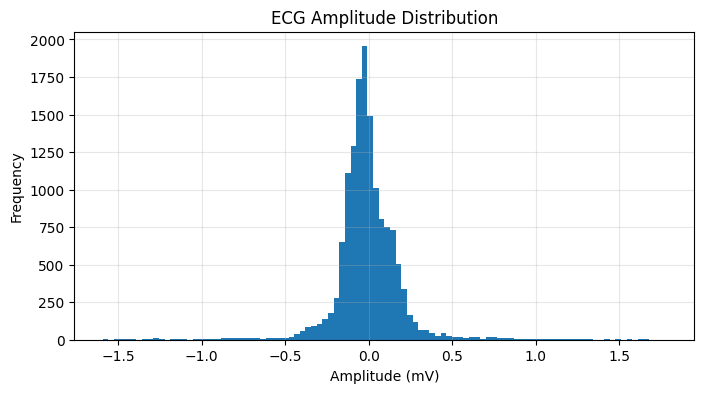

In [13]:
plt.figure(figsize=(8,4))
plt.hist(signal.flatten(), bins=100)

plt.title("ECG Amplitude Distribution")
plt.xlabel("Amplitude (mV)")
plt.ylabel("Frequency")

plt.grid(alpha=0.3)
plt.show()

In [14]:
for i, lead in enumerate(lead_names):
  lead_signal = signal[:, i]

  print(f"{lead}")
  print("min:", np.min(lead_signal))
  print("max:", np.max(lead_signal))
  print("mean:", np.mean(lead_signal))
  print("std:", np.std(lead_signal))
  print()

I
min: -0.128
max: 0.836
mean: -0.005288333333333335
std: 0.13619253600652603

II
min: -0.457
max: 1.103
mean: -0.007426666666666663
std: 0.2277486435134625

III
min: -0.418
max: 0.402
mean: -0.00912916666666666
std: 0.1701406696902269

aVR
min: -0.937
max: 0.271
mean: -0.0038091666666666664
std: 0.1674150861859196

aVL
min: -0.206
max: 0.497
mean: -0.0031424999999999977
std: 0.10407544792320937

aVF
min: -0.418
max: 0.727
mean: -0.008139166666666664
std: 0.18927352288677946

V1
min: -1.592
max: 0.339
mean: 0.007490000000000001
std: 0.30053775675168226

V2
min: -0.885
max: 0.247
mean: -0.0064283333333333345
std: 0.1516414186951866

V3
min: -1.398
max: 1.31
mean: -0.008015833333333333
std: 0.31609731716035205

V4
min: -0.841
max: 1.78
mean: -0.008885833333333332
std: 0.29670004403882194

V5
min: -0.332
max: 1.349
mean: -0.03032333333333333
std: 0.22786435026616653

V6
min: -0.15
max: 0.894
mean: -0.005561666666666664
std: 0.14772716810804376



### Reading first lead ECG

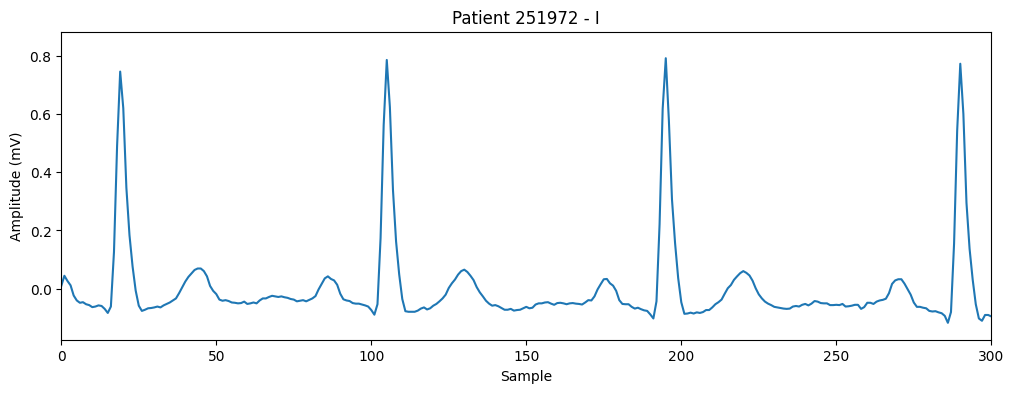

In [15]:
plt.figure(figsize=(12, 4))
plt.plot(signals[:, 0])
plt.title(f'Patient {patient_id} - {lead_names[0]}')
plt.xlabel('Sample')
plt.ylabel('Amplitude (mV)')
plt.xlim(0, 300)
plt.show()

### Reading all leads ECG

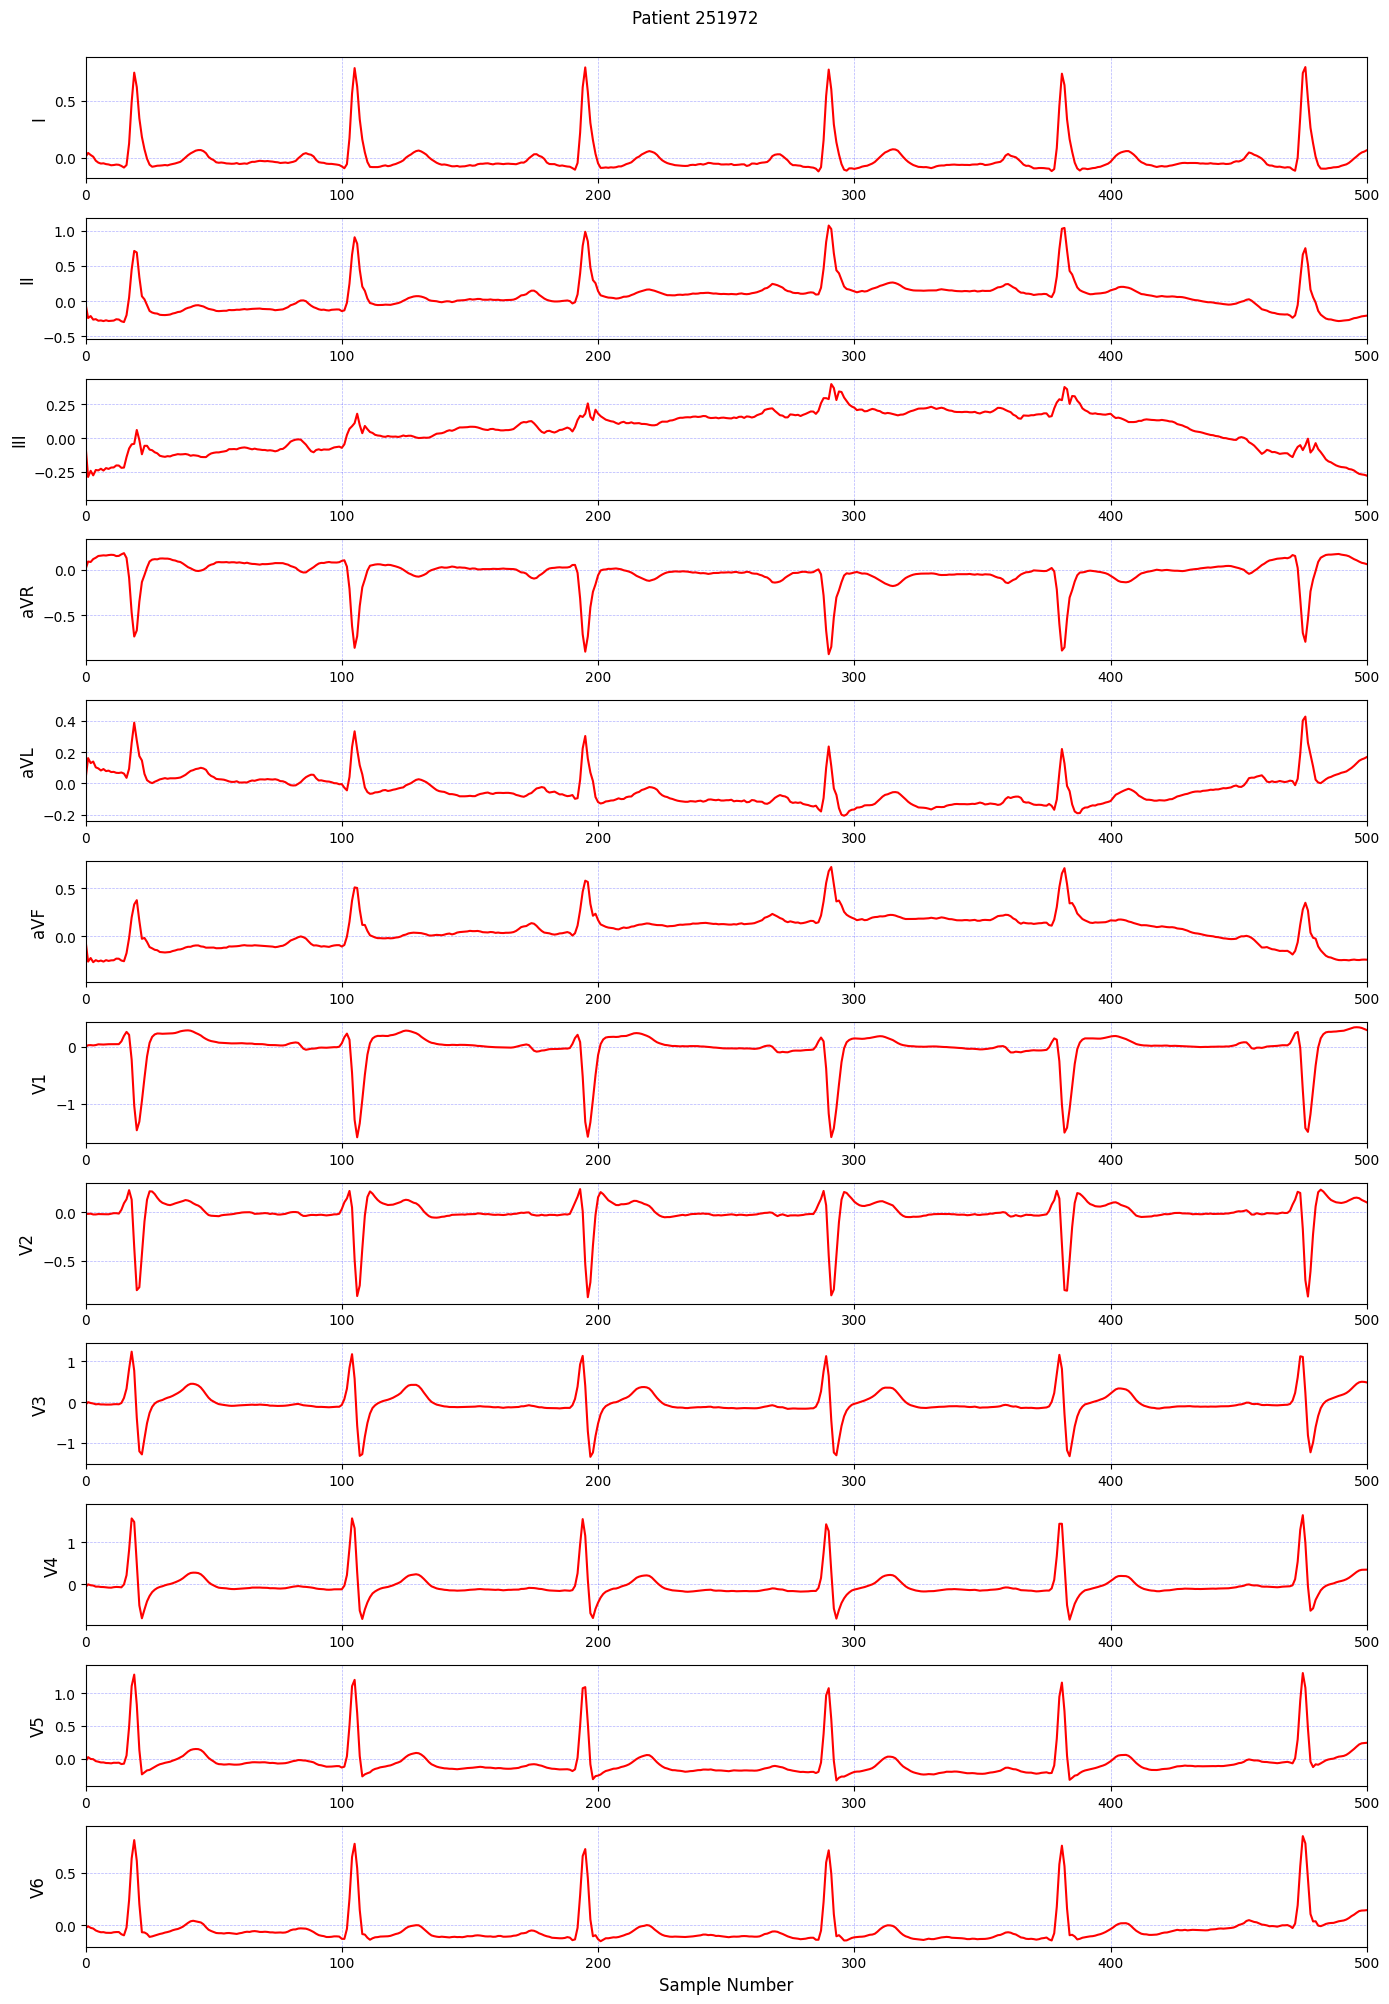

In [16]:
fig, axes = plt.subplots(12, 1, figsize=(14, 20))

for i, lead_name in enumerate(lead_names):
  axes[i].plot(signals[:, i], linewidth=1.5, color='red')
  axes[i].set_ylabel(lead_name, fontsize=12, fontweight='medium')
  axes[i].grid(True, linestyle='--', linewidth=0.5, color='blue', alpha=0.3)

  # focusing waveform at specific time (0, duration)
  axes[i].set_xlim(0, 500) 

plt.suptitle(f'Patient {patient_id}', y=1)
plt.xlabel('Sample Number', fontsize=12)
plt.tight_layout()
plt.show()

#### Normal VS Brugada ECG (Lead V1)

In [17]:
normal_patient_id = '251972'
normal_record = wfdb.rdrecord(f'files/{normal_patient_id}/{normal_patient_id}')

In [18]:
brugada_patient_id = '509648'
brugada_record = wfdb.rdrecord(f'files/{brugada_patient_id}/{brugada_patient_id}')

In [19]:
focus_indices = [6,7,8]  # V1 V2 V3
focus_leads = lead_names[6:9]

### Exploratory Data Analysis (EDA)

In [20]:
df = pd.DataFrame(signals, columns=lead_names)
df.head()

,I,II,III,aVR,aVL,aVF,V1,V2,V3,V4,V5,V6
0,0.009,-0.035,-0.052,0.003,0.026,-0.042,-0.002,-0.019,-0.062,-0.063,-0.044,-0.027
1,0.044,-0.240,-0.290,0.088,0.162,-0.263,0.023,-0.019,-0.003,-0.001,0.024,-0.008
2,0.026,-0.212,-0.244,0.083,0.130,-0.226,0.025,-0.017,-0.024,-0.022,-0.004,-0.023
3,0.011,-0.262,-0.278,0.115,0.140,-0.269,0.020,-0.025,-0.036,-0.029,-0.008,-0.030
4,-0.024,-0.256,-0.238,0.130,0.103,-0.248,0.026,-0.025,-0.056,-0.055,-0.037,-0.048


In [21]:
df.shape

(1200, 12)

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   I       1200 non-null   float64
 1   II      1200 non-null   float64
 2   III     1200 non-null   float64
 3   aVR     1200 non-null   float64
 4   aVL     1200 non-null   float64
 5   aVF     1200 non-null   float64
 6   V1      1200 non-null   float64
 7   V2      1200 non-null   float64
 8   V3      1200 non-null   float64
 9   V4      1200 non-null   float64
 10  V5      1200 non-null   float64
 11  V6      1200 non-null   float64
dtypes: float64(12)
memory usage: 112.6 KB


In [23]:
df.describe()

,I,II,III,aVR,aVL,aVF,V1,V2,V3,V4,V5,V6
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,-0.005288,-0.007427,-0.009129,-0.003809,-0.003142,-0.008139,0.007490,-0.006428,-0.008016,-0.008886,-0.030323,-0.005562
std,0.136249,0.227844,0.170212,0.167485,0.104119,0.189352,0.300663,0.151705,0.316229,0.296824,0.227959,0.147789
min,-0.128000,-0.457000,-0.418000,-0.937000,-0.206000,-0.418000,-1.592000,-0.885000,-1.398000,-0.841000,-0.332000,-0.150000
25%,-0.063000,-0.152250,-0.131000,-0.044000,-0.090250,-0.144000,-0.013000,-0.027000,-0.116250,-0.130000,-0.139000,-0.079250
50%,-0.045000,-0.027000,-0.002000,0.019000,-0.015000,-0.018000,0.052500,-0.010000,-0.046500,-0.062000,-0.080000,-0.034000
75%,0.001000,0.119000,0.151000,0.083000,0.063000,0.138000,0.141000,0.066000,0.068250,0.026000,0.000000,0.013000
max,0.836000,1.103000,0.402000,0.271000,0.497000,0.727000,0.339000,0.247000,1.310000,1.780000,1.349000,0.894000


In [25]:
missing_value = df.isnull().sum()
print(missing_value)

I      0
II     0
III    0
aVR    0
aVL    0
aVF    0
V1     0
V2     0
V3     0
V4     0
V5     0
V6     0
dtype: int64


In [26]:
nan_values = df.isna().sum()
print(nan_values)

I      0
II     0
III    0
aVR    0
aVL    0
aVF    0
V1     0
V2     0
V3     0
V4     0
V5     0
V6     0
dtype: int64
